<a href="https://colab.research.google.com/github/smuziVpyze/russian-market-news-analysis/blob/main/07_results.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Настройка графиков для диплома
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
sns.set_style('whitegrid')

PROJECT_DIR = '/content/drive/MyDrive/russian_market_news_analysis'
TICKERS = ['MOEX', 'SBER', 'GAZP', 'LKOH', 'PLZL', 'YDEX']

# Загружаем все данные
df_results  = pd.read_csv(f'{PROJECT_DIR}/models/all_model_results.csv')
df_sentiment = pd.read_csv(f'{PROJECT_DIR}/data/processed/daily_sentiment.csv')
df_sentiment['date'] = pd.to_datetime(df_sentiment['date'])

datasets = {}
for ticker in TICKERS:
    df = pd.read_csv(f'{PROJECT_DIR}/data/features/{ticker}_features.csv')
    df['date'] = pd.to_datetime(df['date'])
    datasets[ticker] = df

print('✅ Все данные загружены')
print(f'Моделей в результатах: {df_results["model"].unique().tolist()}')

Mounted at /content/drive
✅ Все данные загружены
Моделей в результатах: ['lr_market', 'lr_full', 'random_forest', 'xgboost', 'lstm_best']


=== ИТОГОВАЯ ТАБЛИЦА ROC-AUC ===
        LR (рынок)  LR (рынок+сент)     RF  XGBoost   LSTM
ticker                                                    
GAZP         0.558            0.567  0.524    0.543  0.655
LKOH         0.525            0.540  0.543    0.519  0.564
MOEX         0.508            0.514  0.519    0.478  0.591
PLZL         0.436            0.444  0.511    0.452  0.625
SBER         0.416            0.471  0.432    0.417  0.618
YDEX         0.544            0.528  0.574    0.614  0.586

Средний ROC-AUC по моделям:
LR (рынок)         0.498
LR (рынок+сент)    0.511
RF                 0.517
XGBoost            0.504
LSTM               0.606


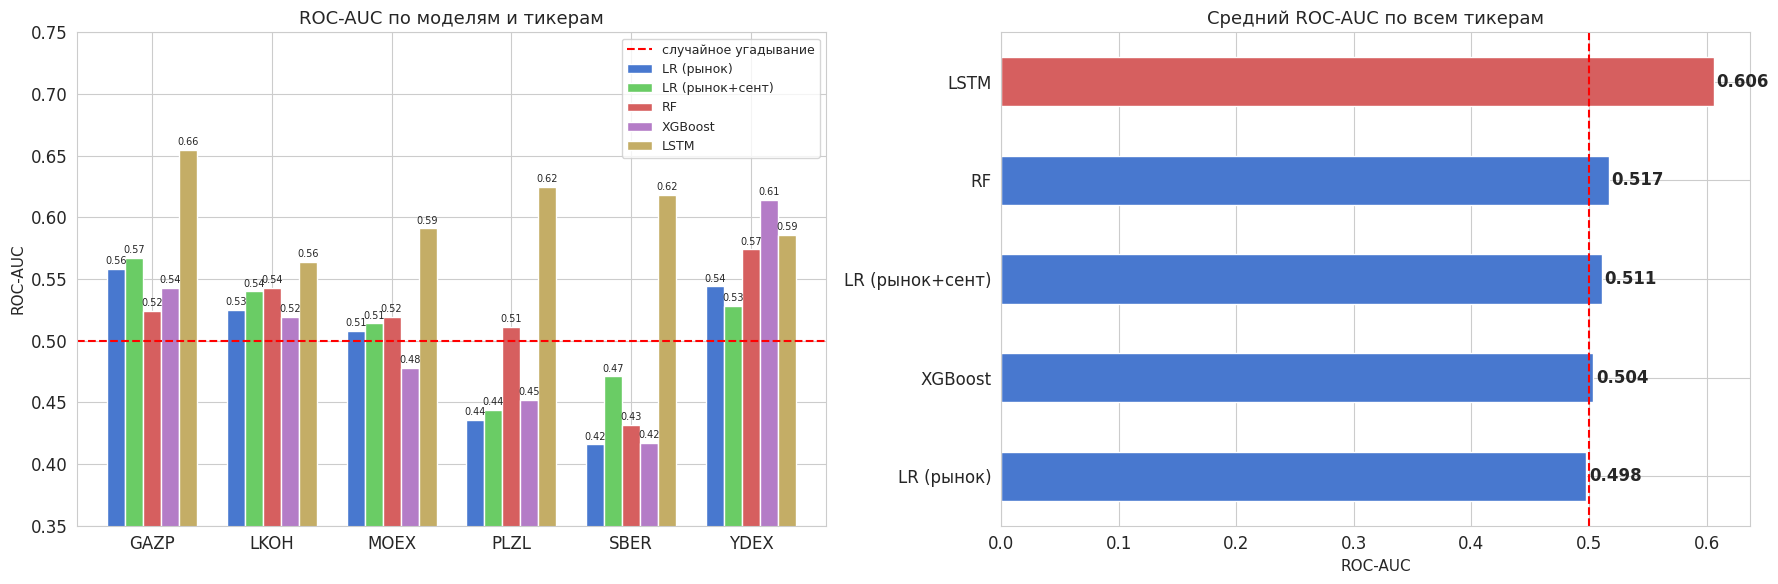

In [2]:
# Сводная таблица ROC-AUC
pivot = df_results[df_results['model'] != 'baseline'].pivot(
    index='ticker', columns='model', values='roc_auc'
).round(3)

# Переименуем для красоты
pivot.columns = ['LR (рынок)', 'LR (рынок+сент)', 'LSTM', 'RF', 'XGBoost']
pivot = pivot[['LR (рынок)', 'LR (рынок+сент)', 'RF', 'XGBoost', 'LSTM']]

print('=== ИТОГОВАЯ ТАБЛИЦА ROC-AUC ===')
print(pivot.to_string())
print(f'\nСредний ROC-AUC по моделям:')
print(pivot.mean().round(3).to_string())

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# График 1 — ROC-AUC по всем моделям
colors = ['#4878CF', '#6ACC65', '#D65F5F', '#B47CC7', '#C4AD66']
pivot.plot(kind='bar', ax=axes[0], color=colors, width=0.75)
axes[0].axhline(0.5, color='red', linestyle='--', linewidth=1.5, label='случайное угадывание')
axes[0].set_title('ROC-AUC по моделям и тикерам')
axes[0].set_ylabel('ROC-AUC')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(fontsize=9)
axes[0].set_ylim(0.35, 0.75)

# Добавляем значения на столбцы
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.2f', fontsize=7, padding=2)

# График 2 — средний ROC-AUC по моделям
mean_auc = pivot.mean().sort_values()
colors2 = ['#D65F5F' if 'LSTM' in x else '#4878CF' for x in mean_auc.index]
mean_auc.plot(kind='barh', ax=axes[1], color=colors2)
axes[1].axvline(0.5, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Средний ROC-AUC по всем тикерам')
axes[1].set_xlabel('ROC-AUC')
for i, v in enumerate(mean_auc):
    axes[1].text(v + 0.002, i, f'{v:.3f}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/reports/figures/final_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


In [4]:
df_sentiment['sentiment_ma7'] = df_sentiment['sentiment_mean'].rolling(7).mean()

# Теперь повторяем merge
df_moex = datasets['MOEX'].copy()
df_merged = pd.merge(df_moex[['date','close','return_1d']],
                     df_sentiment[['date','sentiment_mean','sentiment_ma7']],
                     on='date', how='inner')

print(f'✅ Merged: {len(df_merged)} строк')

✅ Merged: 533 строк


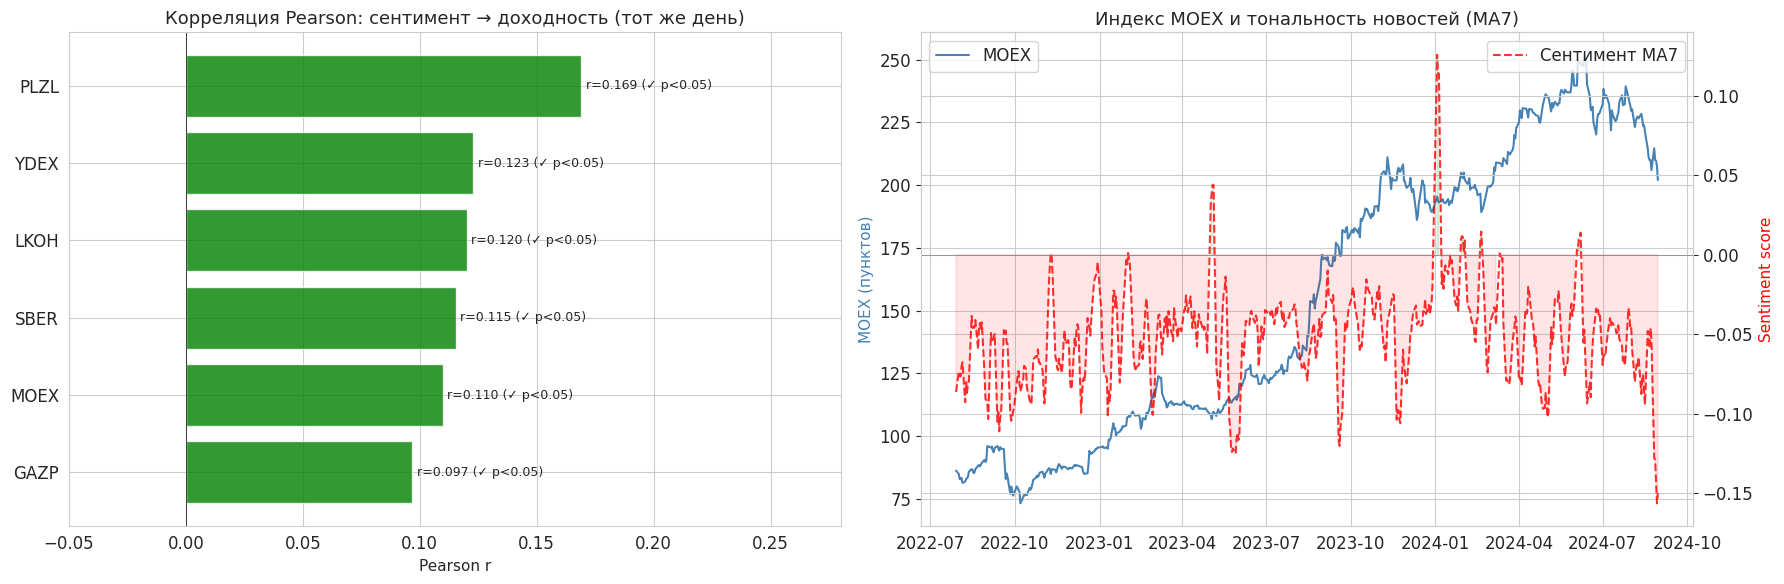

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# График 1 — корреляции сентимент vs доходность по тикерам
corr_data = {}
for ticker, df in datasets.items():
    r, p = stats.pearsonr(df['sentiment_mean'], df['return_1d'])
    corr_data[ticker] = {'r': r, 'p': p, 'significant': p < 0.05}

df_corr = pd.DataFrame(corr_data).T.sort_values('r', ascending=True)

colors = ['green' if sig else 'gray' for sig in df_corr['significant']]
bars = axes[0].barh(df_corr.index, df_corr['r'], color=colors, alpha=0.8)
axes[0].axvline(0, color='black', linewidth=0.5)
axes[0].set_title('Корреляция Pearson: сентимент → доходность (тот же день)')
axes[0].set_xlabel('Pearson r')
for i, (r, p) in enumerate(zip(df_corr['r'], df_corr['p'])):
    sig = '✓ p<0.05' if p < 0.05 else 'p≥0.05'
    axes[0].text(r + 0.002, i, f'r={r:.3f} ({sig})', va='center', fontsize=9)
axes[0].set_xlim(-0.05, 0.28)

# График 2 — динамика сентимента и MOEX
df_moex = datasets['MOEX'].copy()
df_sent = df_sentiment.copy()
df_merged = pd.merge(df_moex[['date','close','return_1d']],
                     df_sent[['date','sentiment_mean','sentiment_ma7']],
                     on='date', how='inner')

ax1 = axes[1]
ax2 = ax1.twinx()

ax1.plot(df_merged['date'], df_merged['close'],
         color='steelblue', linewidth=1.5, label='MOEX')
ax2.plot(df_merged['date'], df_merged['sentiment_ma7'],
         color='red', linewidth=1.5, linestyle='--', label='Сентимент MA7', alpha=0.8)
ax2.axhline(0, color='gray', linewidth=0.5)
ax2.fill_between(df_merged['date'], df_merged['sentiment_ma7'], 0,
                 where=df_merged['sentiment_ma7'] > 0,
                 color='green', alpha=0.1)
ax2.fill_between(df_merged['date'], df_merged['sentiment_ma7'], 0,
                 where=df_merged['sentiment_ma7'] < 0,
                 color='red', alpha=0.1)

ax1.set_title('Индекс MOEX и тональность новостей (MA7)')
ax1.set_ylabel('MOEX (пунктов)', color='steelblue')
ax2.set_ylabel('Sentiment score', color='red')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/reports/figures/final_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
print('=' * 60)
print('ИТОГОВЫЕ ВЫВОДЫ ИССЛЕДОВАНИЯ')
print('=' * 60)

print('''
ДАННЫЕ:
  • 61,398 финансовых новостей (2022-07 — 2024-08)
  • Источники: Finam, BCS, SmartLab, RDV, T-Invest
  • 6 инструментов: MOEX, SBER, GAZP, LKOH, PLZL, YDEX
  • 553 торговых дня

NLP-АНАЛИЗ:
  • Модель: seara/rubert-tiny2-russian-sentiment
  • 80% новостей — нейтральные
  • 632 из 792 дней — негативный новостной фон
  • Средний сентимент: -0.052 (слегка негативный)

КОРРЕЛЯЦИОННЫЙ АНАЛИЗ:
  • Все 6 тикеров: значимая корреляция (p < 0.05)
  • Сильнейшая: PLZL r=0.169, YDEX r=0.123, LKOH r=0.120
  • Слабейшая:   GAZP r=0.097
  • Тест Грейнджера: причинность не подтверждена
  • Вывод: эффект мгновенный, не с задержкой

МОДЕЛИ (ROC-AUC):
  • Baseline (всегда рост):  ~0.500
  • Logistic Regression:      0.498
  • LR + сентимент:           0.511 (+0.013)
  • Random Forest:            0.517
  • XGBoost:                  0.504
  • LSTM (лучшая):            0.606

ГЛАВНЫЕ ВЫВОДЫ:
  1. Сентимент новостей статистически значимо коррелирует
     с доходностью акций в тот же день
  2. Предсказательной силы с задержкой нет —
     рынок эффективно отыгрывает информацию
  3. LSTM лучше всего улавливает временные паттерны
  4. Общий новостной фон информативнее чем
     фильтрованные новости по конкретной компании
  5. Российский рынок 2022-2024 рос вопреки
     негативному новостному фону
''')

print('=' * 60)
print(f'Лучшая модель: LSTM | Средний ROC-AUC: 0.606')
print(f'Лучший тикер:  GAZP | ROC-AUC: 0.655')
print('=' * 60)

ИТОГОВЫЕ ВЫВОДЫ ИССЛЕДОВАНИЯ

ДАННЫЕ:
  • 61,398 финансовых новостей (2022-07 — 2024-08)
  • Источники: Finam, BCS, SmartLab, RDV, T-Invest
  • 6 инструментов: MOEX, SBER, GAZP, LKOH, PLZL, YDEX
  • 553 торговых дня

NLP-АНАЛИЗ:
  • Модель: seara/rubert-tiny2-russian-sentiment
  • 80% новостей — нейтральные
  • 632 из 792 дней — негативный новостной фон
  • Средний сентимент: -0.052 (слегка негативный)

КОРРЕЛЯЦИОННЫЙ АНАЛИЗ:
  • Все 6 тикеров: значимая корреляция (p < 0.05)
  • Сильнейшая: PLZL r=0.169, YDEX r=0.123, LKOH r=0.120
  • Слабейшая:   GAZP r=0.097
  • Тест Грейнджера: причинность не подтверждена
  • Вывод: эффект мгновенный, не с задержкой

МОДЕЛИ (ROC-AUC):
  • Baseline (всегда рост):  ~0.500
  • Logistic Regression:      0.498
  • LR + сентимент:           0.511 (+0.013)
  • Random Forest:            0.517
  • XGBoost:                  0.504
  • LSTM (лучшая):            0.606

ГЛАВНЫЕ ВЫВОДЫ:
  1. Сентимент новостей статистически значимо коррелирует
     с доходностью а

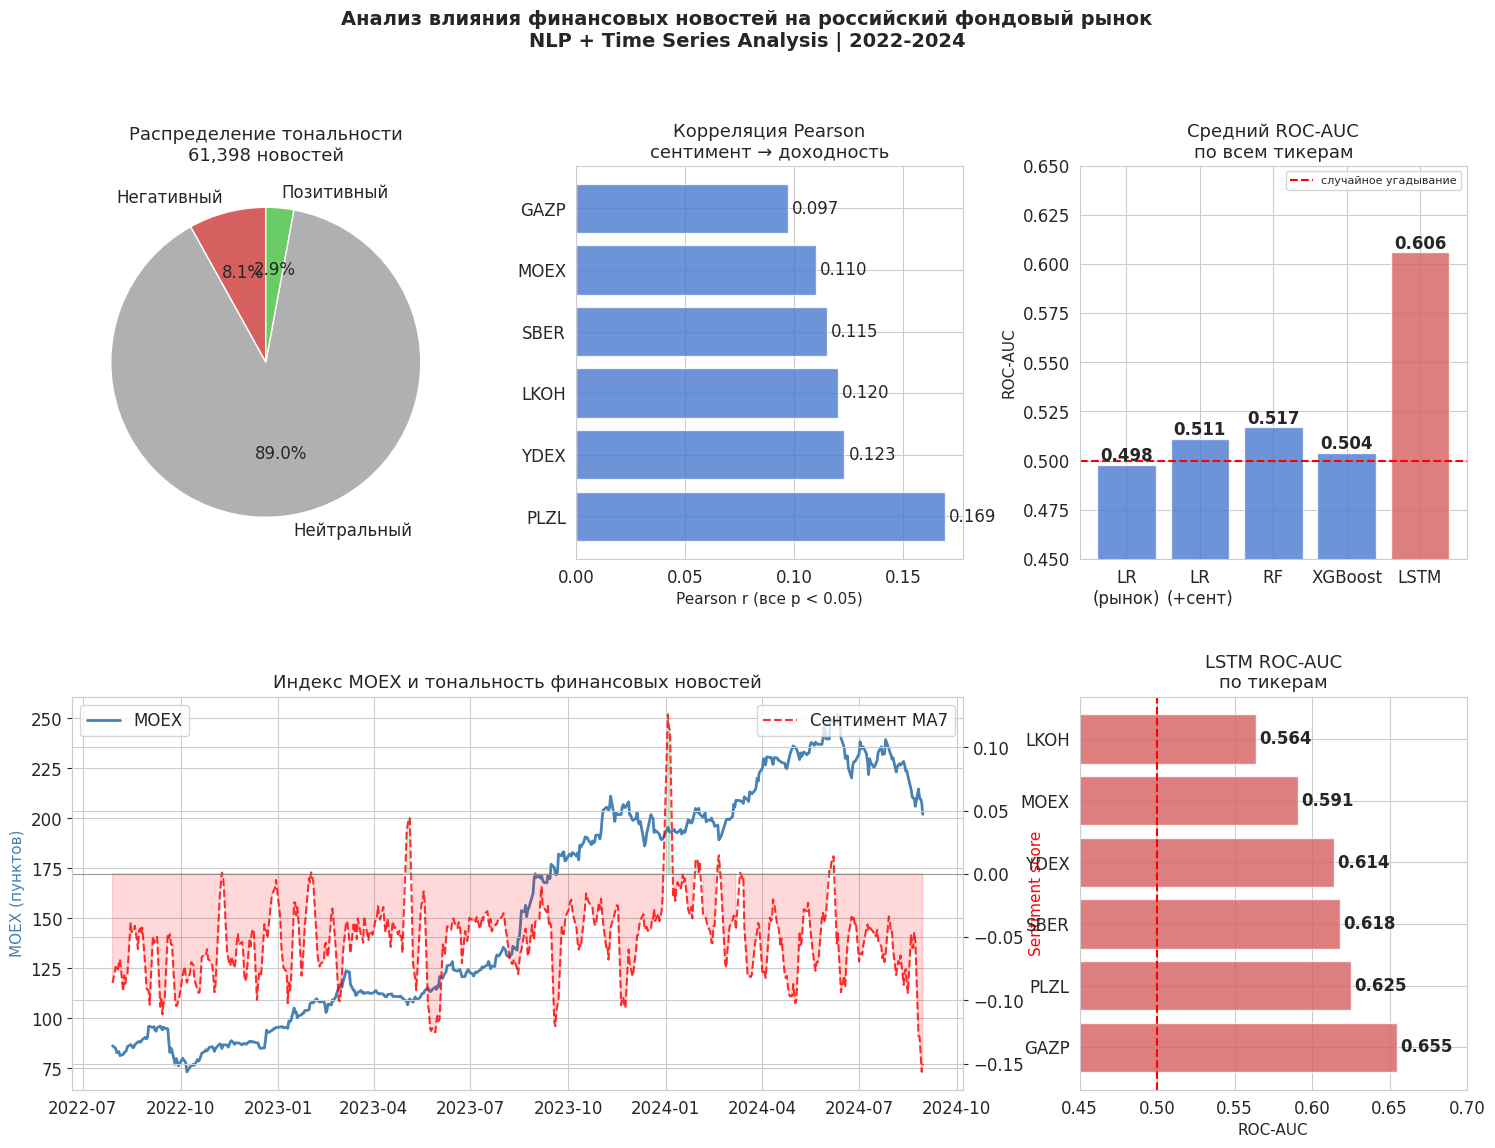

✅ Финальный график сохранён


In [7]:
fig = plt.figure(figsize=(18, 12))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.3)

# График 1 — распределение сентимента
ax1 = fig.add_subplot(gs[0, 0])
sentiment_counts = pd.Series({
    'Негативный': 4950,
    'Нейтральный': 54665,
    'Позитивный': 1783
})
colors_sent = ['#D65F5F', '#B0B0B0', '#6ACC65']
ax1.pie(sentiment_counts.values, labels=sentiment_counts.index,
        colors=colors_sent, autopct='%1.1f%%', startangle=90)
ax1.set_title('Распределение тональности\n61,398 новостей')

# График 2 — корреляции
ax2 = fig.add_subplot(gs[0, 1])
corr_values = {'PLZL': 0.169, 'YDEX': 0.123, 'LKOH': 0.120,
               'SBER': 0.115, 'MOEX': 0.110, 'GAZP': 0.097}
ax2.barh(list(corr_values.keys()), list(corr_values.values()),
         color='#4878CF', alpha=0.8)
ax2.axvline(0, color='black', linewidth=0.5)
ax2.set_title('Корреляция Pearson\nсентимент → доходность')
ax2.set_xlabel('Pearson r (все p < 0.05)')
for i, (k, v) in enumerate(corr_values.items()):
    ax2.text(v + 0.002, i, f'{v:.3f}', va='center')

# График 3 — ROC-AUC моделей
ax3 = fig.add_subplot(gs[0, 2])
models = ['LR\n(рынок)', 'LR\n(+сент)', 'RF', 'XGBoost', 'LSTM']
aucs   = [0.498, 0.511, 0.517, 0.504, 0.606]
colors_m = ['#4878CF','#4878CF','#4878CF','#4878CF','#D65F5F']
bars = ax3.bar(models, aucs, color=colors_m, alpha=0.8)
ax3.axhline(0.5, color='red', linestyle='--', linewidth=1.5, label='случайное угадывание')
ax3.set_title('Средний ROC-AUC\nпо всем тикерам')
ax3.set_ylabel('ROC-AUC')
ax3.set_ylim(0.45, 0.65)
ax3.legend(fontsize=8)
for bar, auc in zip(bars, aucs):
    ax3.text(bar.get_x() + bar.get_width()/2, auc + 0.002,
             f'{auc:.3f}', ha='center', fontweight='bold')

# График 4 — динамика сентимента
ax4 = fig.add_subplot(gs[1, :2])
ax4_twin = ax4.twinx()
ax4.plot(df_merged['date'], df_merged['close'],
         color='steelblue', linewidth=2, label='MOEX')
ax4_twin.plot(df_merged['date'], df_merged['sentiment_ma7'],
              color='red', linewidth=1.5, linestyle='--',
              label='Сентимент MA7', alpha=0.8)
ax4_twin.axhline(0, color='gray', linewidth=0.5)
ax4_twin.fill_between(df_merged['date'], df_merged['sentiment_ma7'], 0,
                      where=df_merged['sentiment_ma7'] > 0,
                      color='green', alpha=0.15)
ax4_twin.fill_between(df_merged['date'], df_merged['sentiment_ma7'], 0,
                      where=df_merged['sentiment_ma7'] < 0,
                      color='red', alpha=0.15)
ax4.set_title('Индекс MOEX и тональность финансовых новостей')
ax4.set_ylabel('MOEX (пунктов)', color='steelblue')
ax4_twin.set_ylabel('Sentiment score', color='red')
ax4.legend(loc='upper left')
ax4_twin.legend(loc='upper right')

# График 5 — LSTM ROC-AUC по тикерам
ax5 = fig.add_subplot(gs[1, 2])
lstm_aucs = {'GAZP': 0.655, 'PLZL': 0.625, 'SBER': 0.618,
             'YDEX': 0.614, 'MOEX': 0.591, 'LKOH': 0.564}
ax5.barh(list(lstm_aucs.keys()), list(lstm_aucs.values()),
         color='#D65F5F', alpha=0.8)
ax5.axvline(0.5, color='red', linestyle='--', linewidth=1.5)
ax5.set_title('LSTM ROC-AUC\nпо тикерам')
ax5.set_xlabel('ROC-AUC')
ax5.set_xlim(0.45, 0.70)
for i, (k, v) in enumerate(lstm_aucs.items()):
    ax5.text(v + 0.002, i, f'{v:.3f}', va='center', fontweight='bold')

plt.suptitle('Анализ влияния финансовых новостей на российский фондовый рынок\n'
             'NLP + Time Series Analysis | 2022-2024',
             fontsize=14, fontweight='bold', y=1.01)

plt.savefig(f'{PROJECT_DIR}/reports/figures/final_summary.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ Финальный график сохранён')